**Idea**

The main idea is to understand how the hidden cargo inspection system makes its decisions. Since the internal model is not visible, we treat it as a black box. We give different shipment manifests as input, observe the returned score and decision, and use those observations to discover patterns.What we are doing
First, we send multiple valid shipment queries to the black-box system. Each query becomes one row in our dataset.
Our dataset therefore looks roughly like:
input shipment features → score → decision
Then we use this collected data to train our own machine-learning model.
We actually have two prediction tasks:
- Predict the score, which is a numerical value from 0 to 1. This is a regression problem.
- Predict the decision, either APPROVE or DECLINE. This is a classification problem.
We split our collected data into training and testing data. We train different models and compare their performance. The model that best reproduces the outputs of the hidden system becomes our reconstructed model.
We also study feature importance to understand which shipment fields have the strongest effect on the hidden system.

In [ ]:
# Colab already has sklearn, xgboost, pandas etc. CatBoost may need installing.
!pip install -q catboost xgboost

import numpy as np, pandas as pd, math, joblib, warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
                                     cross_validate, cross_val_score,
                                     cross_val_predict, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              RandomForestClassifier)
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score)
from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

SEED = 42
sns.set_theme(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [ ]:
# Upload your CSV when prompted (or set CSV_PATH manually if it's already in Colab)
from google.colab import files
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]

df = pd.read_csv(CSV_PATH)

FEATURES = ["container_count", "declared_value", "discrepancy_ratio", "port",
            "prior_shipments", "recent_seizures", "route_age_days",
            "shipper_score", "shipper_years", "transfers"]
PORTS = ["A", "B", "C", "D"]

# Make sure all expected columns are there
missing_cols = [c for c in FEATURES + ["score", "decision"] if c not in df.columns]
assert not missing_cols, f"Missing columns in CSV: {missing_cols}"

# Clean text columns (removes accidental spaces / lowercase)
df["port"] = df["port"].astype(str).str.strip().str.upper()
df["decision"] = df["decision"].astype(str).str.strip().str.upper()
print("Loaded:", CSV_PATH)

Saving blackbox_r2_queries.csv to blackbox_r2_queries.csv
Loaded: blackbox_r2_queries.csv


In [ ]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
display(df.head(10))

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

n_dup = df.duplicated().sum()
print("\nDuplicate rows:", n_dup)

print("\nStatistics (numeric):")
display(df.describe().T)

print("\nCategory counts:")
print(df["port"].value_counts(), "\n")
print(df["decision"].value_counts())

# Check values against the ranges you described
ranges = {"container_count": (0, 100), "declared_value": (0, 100),
          "discrepancy_ratio": (0, 1), "prior_shipments": (0, 20),
          "recent_seizures": (0, 5), "route_age_days": (18, 75),
          "shipper_score": (300, 900), "shipper_years": (0, 40),
          "transfers": (0, 6), "score": (0, 1)}
for col, (lo, hi) in ranges.items():
    bad = ((df[col] < lo) | (df[col] > hi)).sum()
    if bad:
        print(f"WARNING: {bad} values of {col} outside [{lo}, {hi}]")

# Exact duplicates can land in both train and test and inflate results,
# so we drop them (only if any exist). Rows without a target are unusable.
df = df.drop_duplicates().dropna(subset=["score", "decision"]).reset_index(drop=True)
print("\nShape after cleaning:", df.shape)

assert set(df["decision"].unique()) <= {"APPROVE", "DECLINE"}, "Unexpected decision labels!"

Shape: (150, 13)

Columns: ['query_id', 'score', 'decision', 'container_count', 'declared_value', 'discrepancy_ratio', 'port', 'prior_shipments', 'recent_seizures', 'route_age_days', 'shipper_score', 'shipper_years', 'transfers']


,query_id,score,decision,container_count,declared_value,discrepancy_ratio,port,prior_shipments,recent_seizures,route_age_days,shipper_score,shipper_years,transfers
0,R2 · 170,0.9753,APPROVE,100,5,0.90,A,20,4,23.0,890,31.0,6
1,R2 · 169,0.9774,APPROVE,100,5,0.90,D,20,4,23.0,890,31.0,6
2,R2 · 168,0.9774,APPROVE,100,4,0.90,D,20,4,23.0,890,31.0,6
3,R2 · 167,0.9773,APPROVE,100,4,0.97,D,20,4,23.0,890,31.0,6
4,R2 · 166,0.9762,APPROVE,100,4,0.94,D,20,4,23.0,890,31.0,6
5,R2 · 165,0.9770,APPROVE,100,4,0.96,D,20,4,23.0,890,31.0,6
6,R2 · 164,0.9744,APPROVE,100,4,0.89,D,20,4,23.0,890,31.0,6
7,R2 · 163,0.9766,APPROVE,100,4,0.99,D,20,4,23.0,890,31.0,6
8,R2 · 162,0.9774,APPROVE,100,4,0.90,D,20,4,23.0,890,31.0,6
9,R2 · 161,0.9774,APPROVE,100,4,0.90,D,20,4,23.0,890,31.0,3



Data types:
query_id              object
score                float64
decision              object
container_count        int64
declared_value         int64
discrepancy_ratio    float64
port                  object
prior_shipments        int64
recent_seizures        int64
route_age_days       float64
shipper_score          int64
shipper_years        float64
transfers              int64
dtype: object

Missing values per column:
query_id             0
score                0
decision             0
container_count      0
declared_value       0
discrepancy_ratio    0
port                 0
prior_shipments      0
recent_seizures      0
route_age_days       0
shipper_score        0
shipper_years        0
transfers            0
dtype: int64

Duplicate rows: 0

Statistics (numeric):


,count,mean,std,min,25%,50%,75%,max
score,150.0,0.954004,0.083063,0.043,0.965575,0.9756,0.9765,0.9774
container_count,150.0,88.853333,9.807124,80.000,80.000000,80.0000,100.0000,100.0000
declared_value,150.0,8.613333,18.878555,1.000,4.000000,4.0000,4.0000,100.0000
discrepancy_ratio,150.0,0.867000,0.163333,0.000,0.900000,0.9000,0.9000,1.0000
prior_shipments,150.0,10.006667,9.907963,0.000,0.000000,14.0000,20.0000,20.0000
recent_seizures,150.0,3.900000,0.682966,0.000,4.000000,4.0000,4.0000,5.0000
route_age_days,150.0,26.490000,4.973915,18.000,24.000000,27.0000,27.0000,60.0000
shipper_score,150.0,888.993333,62.332244,315.000,898.000000,900.0000,900.0000,900.0000
shipper_years,150.0,31.373333,2.037556,28.000,31.000000,31.0000,31.0000,40.0000
transfers,150.0,3.146667,2.324040,0.000,0.000000,3.5000,6.0000,6.0000



Category counts:
port
D    141
A      7
C      1
B      1
Name: count, dtype: int64 

decision
APPROVE    149
DECLINE      1
Name: count, dtype: int64

Shape after cleaning: (150, 13)


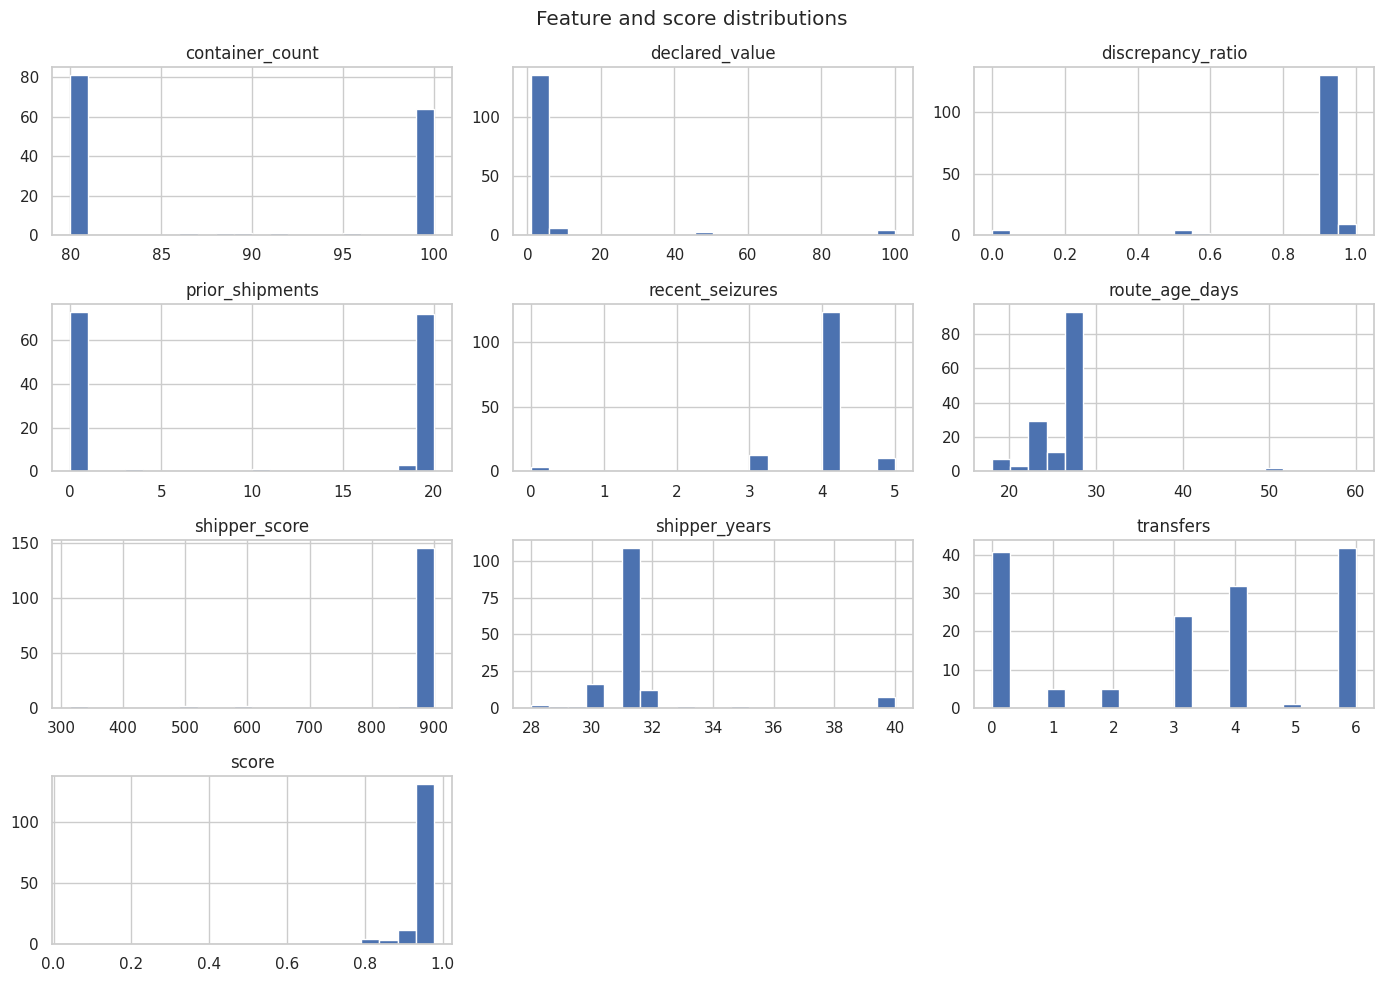

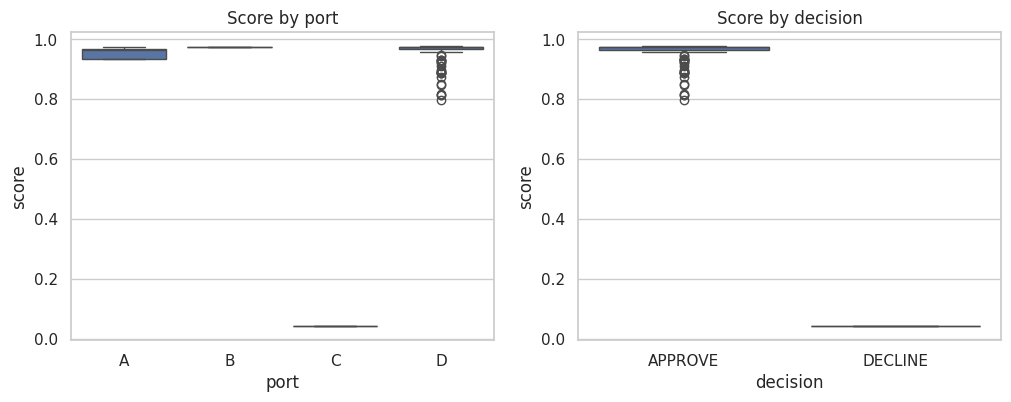

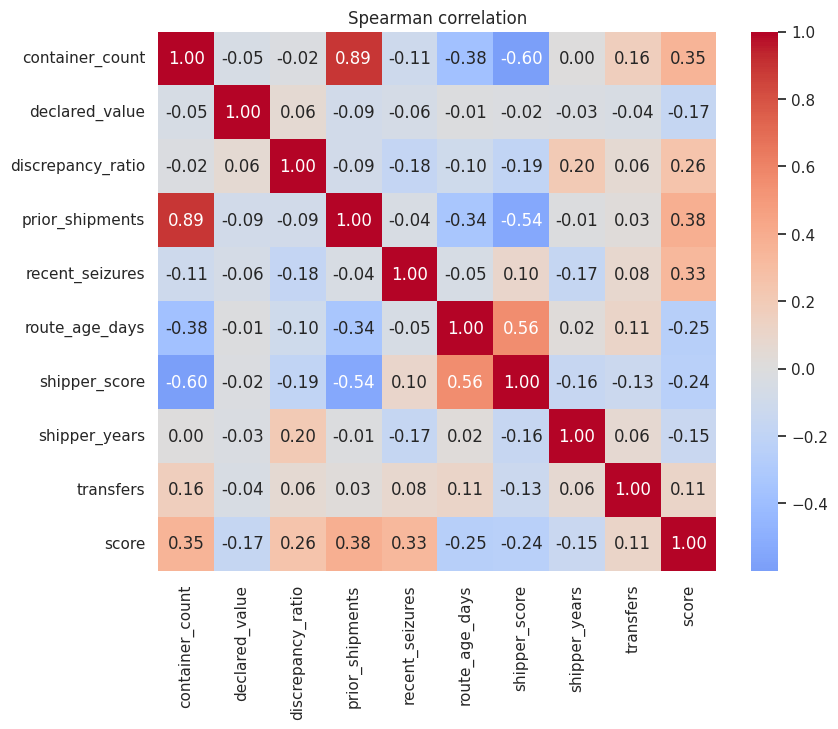

Correlation of each feature with score (sorted by strength):
prior_shipments      0.382329
container_count      0.353106
recent_seizures      0.328669
discrepancy_ratio    0.256038
route_age_days      -0.250239
shipper_score       -0.244418
declared_value      -0.165464
shipper_years       -0.147101
transfers            0.108218
Name: score, dtype: float64


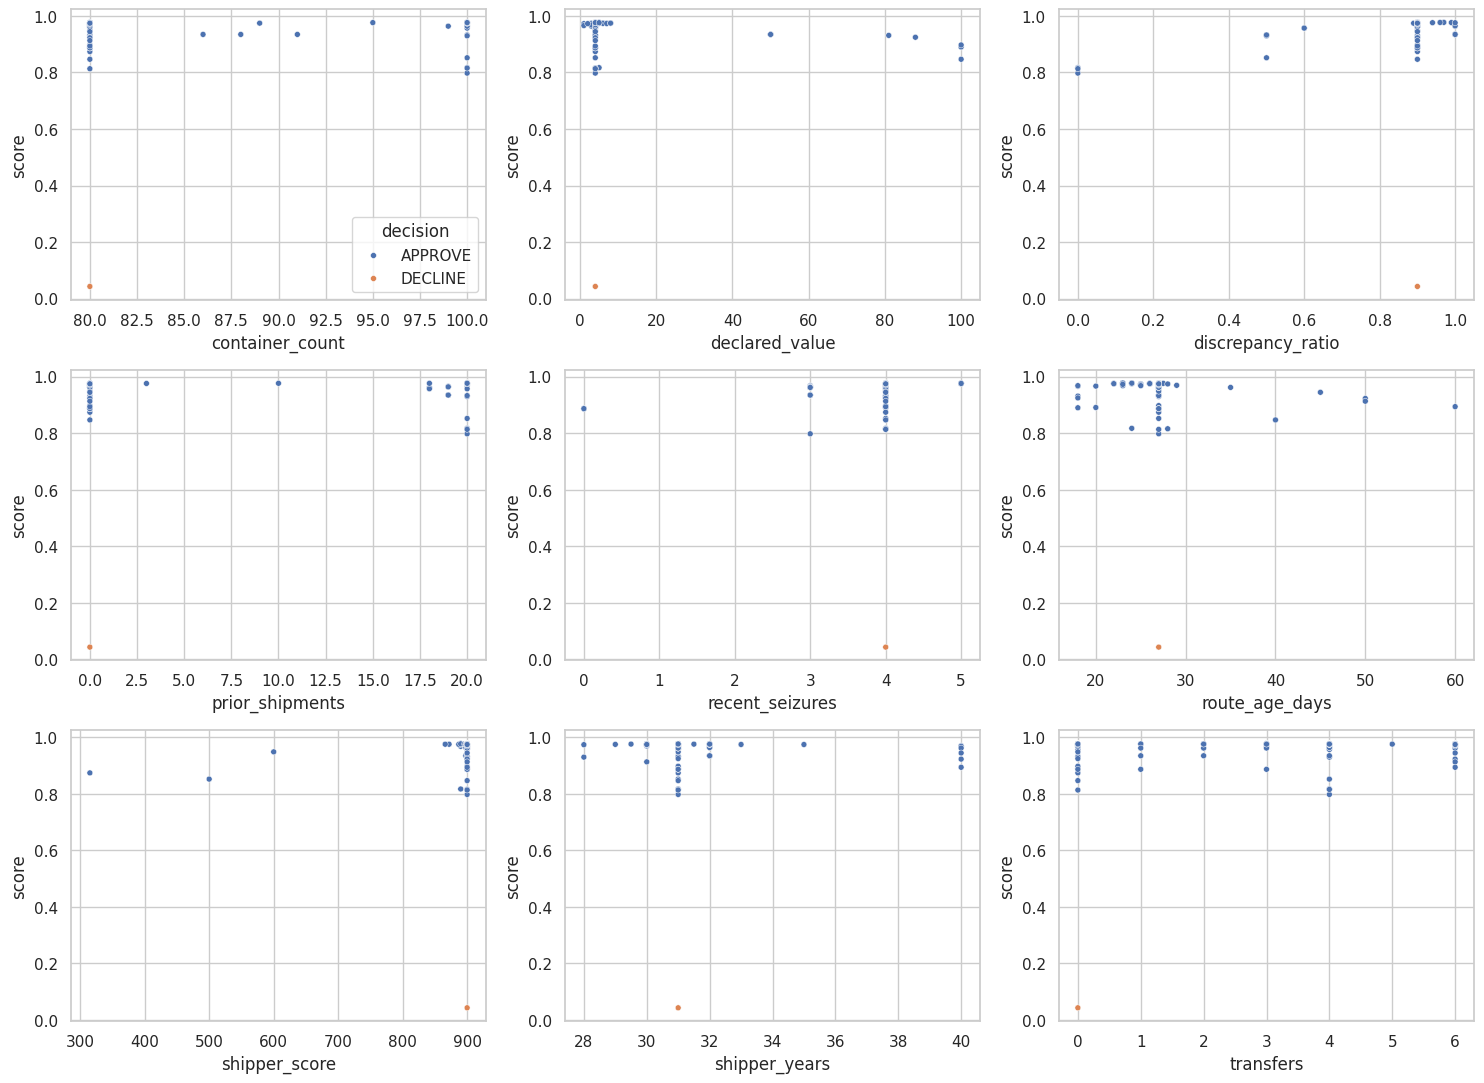

In [ ]:
num_cols = [c for c in FEATURES if c != "port"]

# 1) Distributions
df[num_cols + ["score"]].hist(bins=20, figsize=(14, 10))
plt.suptitle("Feature and score distributions"); plt.tight_layout(); plt.show()

# 2) Score by port and by decision
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="port", y="score", data=df, order=PORTS, ax=ax[0])
sns.boxplot(x="decision", y="score", data=df, ax=ax[1])
ax[0].set_title("Score by port"); ax[1].set_title("Score by decision")
plt.show()

# 3) Correlation with score (Spearman catches monotonic non-linear trends too)
corr = df[num_cols + ["score"]].corr(method="spearman")
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation"); plt.show()

print("Correlation of each feature with score (sorted by strength):")
print(corr["score"].drop("score").sort_values(key=abs, ascending=False))

# 4) Scatter plots of score vs. every numeric feature, coloured by decision
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), num_cols):
    sns.scatterplot(x=col, y="score", hue="decision", data=df, s=18, ax=ax, legend=(col == num_cols[0]))
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42

# Input features
X = df[FEATURES].copy()

# Target = score
y_score = df["score"].astype(float)

# Train-test split
X_train, X_test, ys_train, ys_test = train_test_split(
    X,
    y_score,
    test_size=0.2,
    random_state=SEED
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


# Preprocessing
def make_preprocessor(columns, scale=False):

    numeric_columns = [c for c in columns if c != "port"]

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if scale:
        numeric_steps.append(
            ("scale", StandardScaler())
        )

    preprocessor = ColumnTransformer([
        (
            "num",
            Pipeline(numeric_steps),
            numeric_columns
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    categories=[PORTS],
                    handle_unknown="ignore",
                    sparse_output=False
                ))
            ]),
            ["port"]
        )
    ])

    return preprocessor


def build(model, scale=False, columns=FEATURES):

    return Pipeline([
        ("prep", make_preprocessor(columns, scale)),
        ("model", model)
    ])


# Cross-validation for SCORE prediction
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print("Setup completed successfully ✅")

Train: (120, 10)
Test: (30, 10)
Setup completed successfully ✅


In [ ]:
def reg_models():
    # (model, needs_scaling)
    return {
        "Linear Regression": (LinearRegression(), True),
        "Random Forest":     (RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1), False),
        "Gradient Boosting": (GradientBoostingRegressor(random_state=SEED), False),
        "XGBoost":           (XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                           random_state=SEED, verbosity=0), False),
        "CatBoost":          (CatBoostRegressor(iterations=500, learning_rate=0.05, depth=4,
                                                random_seed=SEED, verbose=0,
                                                allow_writing_files=False), False),
    }

def reg_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {"MAE": mean_absolute_error(y_true, y_pred), "MSE": mse,
            "RMSE": np.sqrt(mse), "R2": r2_score(y_true, y_pred)}

rows, fitted_reg = [], {}
for name, (model, scale) in reg_models().items():
    pipe = build(model, scale)

    # 5-fold CV on the TRAINING set only -> used to choose the best model
    cv = cross_validate(pipe, X_train, ys_train, cv=kf,
                        scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"})
    # Fit on full training set, evaluate once on the held-out test set
    pipe.fit(X_train, ys_train)
    pred = np.clip(pipe.predict(X_test), 0, 1)
    m = reg_metrics(ys_test, pred)
    fitted_reg[name] = pipe
    rows.append({"Model": name,
                 "CV RMSE (mean)": -cv["test_rmse"].mean(), "CV RMSE (std)": cv["test_rmse"].std(),
                 "CV R2 (mean)": cv["test_r2"].mean(),
                 "Test MAE": m["MAE"], "Test MSE": m["MSE"], "Test RMSE": m["RMSE"], "Test R2": m["R2"]})

reg_results = pd.DataFrame(rows).set_index("Model").sort_values("CV RMSE (mean)")
display(reg_results.round(4))

BEST_REG_NAME = reg_results.index[0]          # chosen by CV on train, not by test
print("Best regressor (by CV RMSE):", BEST_REG_NAME)

,CV RMSE (mean),CV RMSE (std),CV R2 (mean),Test MAE,Test MSE,Test RMSE,Test R2
Model,,,,,,,
XGBoost,0.0448,0.0731,0.7458,0.0011,0.0000,0.0016,0.9974
Gradient Boosting,0.0466,0.0723,0.7218,0.0015,0.0000,0.0020,0.9961
Random Forest,0.0477,0.0716,0.7103,0.0016,0.0000,0.0035,0.9880
CatBoost,0.0481,0.0714,0.7030,0.0019,0.0000,0.0026,0.9935
Linear Regression,0.0575,0.0695,0.0133,0.0059,0.0001,0.0085,0.9308


Best regressor (by CV RMSE): XGBoost


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import joblib

# Models for score prediction
models = {
    "Ridge": (Ridge(), True),
    "Random Forest": (
        RandomForestRegressor(n_estimators=200, random_state=42),
        False
    ),
    "Extra Trees": (
        ExtraTreesRegressor(n_estimators=200, random_state=42),
        False
    ),
    "Gradient Boosting": (
        GradientBoostingRegressor(random_state=42),
        False
    )
}

results = []
trained_models = {}

# Train and evaluate models
for name, (model, scale) in models.items():

    pipe = build(model, scale=scale)

    cv_scores = cross_val_score(
        pipe,
        X_train,
        ys_train,
        cv=kf,
        scoring="neg_mean_absolute_error"
    )

    pipe.fit(X_train, ys_train)

    predictions = pipe.predict(X_test)

    mae = mean_absolute_error(ys_test, predictions)
    rmse = np.sqrt(mean_squared_error(ys_test, predictions))
    r2 = r2_score(ys_test, predictions)

    results.append({
        "Model": name,
        "CV MAE": -cv_scores.mean(),
        "Test MAE": mae,
        "Test RMSE": rmse,
        "Test R2": r2
    })

    trained_models[name] = pipe

# Compare results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("CV MAE")

display(results_df)

# Select model using training cross-validation
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]

print("Best model:", best_name)

# Save selected model
joblib.dump(best_model, "blackbox_score_model.pkl")

print("Model saved successfully!")

,Model,CV MAE,Test MAE,Test RMSE,Test R2
2,Extra Trees,0.011324,0.000739,0.001970,0.996300
3,Gradient Boosting,0.012364,0.001450,0.002034,0.996059
1,Random Forest,0.012565,0.001510,0.003337,0.989390
0,Ridge,0.020245,0.007065,0.009829,0.907938


Best model: Extra Trees
Model saved successfully!


SCORE PREDICTION RESULTS
------------------------
MAE : 0.000739
RMSE: 0.00197
R2  : 0.9963


,Actual Score,Predicted Score,Difference
29,0.9769,0.976900,4.440892e-16
22,0.9769,0.976900,4.440892e-16
6,0.9763,0.976300,1.665335e-15
1,0.9757,0.975700,2.109424e-15
2,0.9759,0.975900,2.331468e-15
11,0.9774,0.977400,2.664535e-15
13,0.9774,0.977400,2.664535e-15
4,0.9765,0.976500,3.552714e-15
5,0.9765,0.976500,3.552714e-15
23,0.9765,0.976500,3.552714e-15


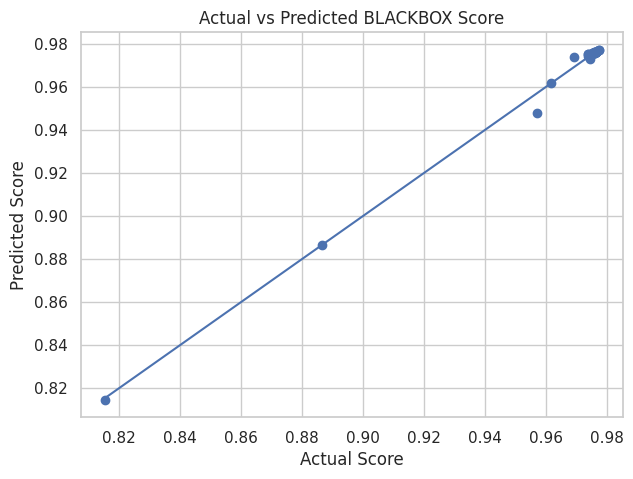


Completed successfully ✅


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predict scores using the best regression model
predicted_scores = best_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(ys_test, predicted_scores)
rmse = np.sqrt(mean_squared_error(ys_test, predicted_scores))
r2 = r2_score(ys_test, predicted_scores)

print("SCORE PREDICTION RESULTS")
print("------------------------")
print("MAE :", round(mae, 6))
print("RMSE:", round(rmse, 6))
print("R2  :", round(r2, 6))

# Compare actual vs predicted
comparison = pd.DataFrame({
    "Actual Score": ys_test.values,
    "Predicted Score": predicted_scores,
    "Difference": np.abs(ys_test.values - predicted_scores)
})

display(comparison.sort_values("Difference").head(20))

# Plot
plt.figure(figsize=(7,5))
plt.scatter(ys_test, predicted_scores)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted BLACKBOX Score")

plt.plot(
    [ys_test.min(), ys_test.max()],
    [ys_test.min(), ys_test.max()]
)

plt.show()

print("\nCompleted successfully ✅")

In [ ]:
# Small grids for every model, but we only tune the one chosen by CV in Section 5.
param_grids = {
    "Linear Regression": {},   # nothing worth tuning
    "Random Forest": {"model__n_estimators": [200, 500], "model__max_depth": [None, 6, 12],
                      "model__min_samples_leaf": [1, 2, 4]},
    "Gradient Boosting": {"model__n_estimators": [200, 400], "model__learning_rate": [0.03, 0.1],
                          "model__max_depth": [2, 3, 4], "model__subsample": [0.8, 1.0]},
    "XGBoost": {"model__n_estimators": [200, 500], "model__learning_rate": [0.03, 0.1],
                "model__max_depth": [3, 4, 6], "model__subsample": [0.8, 1.0]},
    "CatBoost": {"model__iterations": [300, 600], "model__learning_rate": [0.03, 0.1],
                 "model__depth": [3, 4, 6]},
}

grid = param_grids[BEST_REG_NAME]
base_pipe = clone(fitted_reg[BEST_REG_NAME])

if grid:
    n_combos = math.prod(len(v) for v in grid.values())
    search = RandomizedSearchCV(base_pipe, grid, n_iter=min(12, n_combos), cv=kf,
                                scoring="neg_root_mean_squared_error",
                                random_state=SEED, n_jobs=1, refit=True)
    search.fit(X_train, ys_train)                  # tuning sees TRAIN data only
    best_reg = search.best_estimator_
    print("Best params:", search.best_params_)
    print(f"Tuned CV RMSE: {-search.best_score_:.4f}  "
          f"(untuned: {reg_results.loc[BEST_REG_NAME, 'CV RMSE (mean)']:.4f})")
else:
    best_reg = base_pipe.fit(X_train, ys_train)
    print("No tuning needed for", BEST_REG_NAME)

pred = np.clip(best_reg.predict(X_test), 0, 1)
print("\nTuned model on the test set:")
print({k: round(v, 4) for k, v in reg_metrics(ys_test, pred).items()})

Best params: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Tuned CV RMSE: 0.0444  (untuned: 0.0448)

Tuned model on the test set:
{'MAE': 0.0014, 'MSE': 0.0, 'RMSE': np.float64(0.0023), 'R2': 0.995}


,feature,importance,std
2,discrepancy_ratio,0.0388,0.0013
5,recent_seizures,0.0207,0.0004
8,shipper_years,0.0002,0.0002
7,shipper_score,0.0001,0.0001
6,route_age_days,0.0001,0.0001
9,transfers,0.0000,0.0000
4,prior_shipments,0.0000,0.0001
3,port,0.0000,0.0000
1,declared_value,-0.0000,0.0001
0,container_count,-0.0004,0.0002


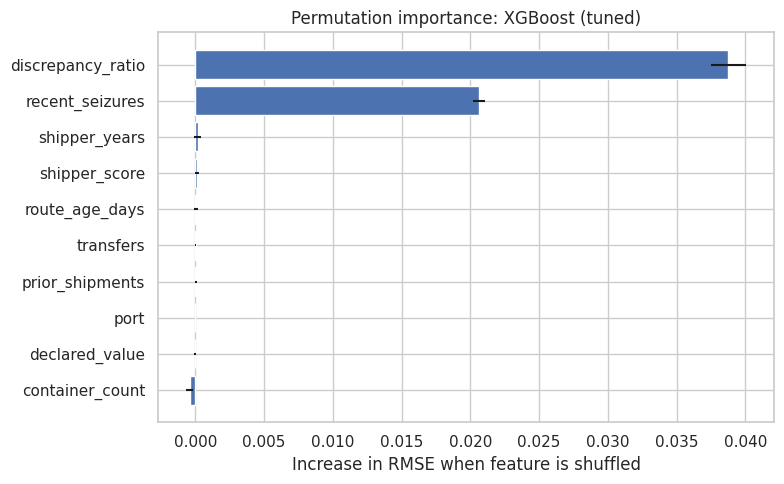

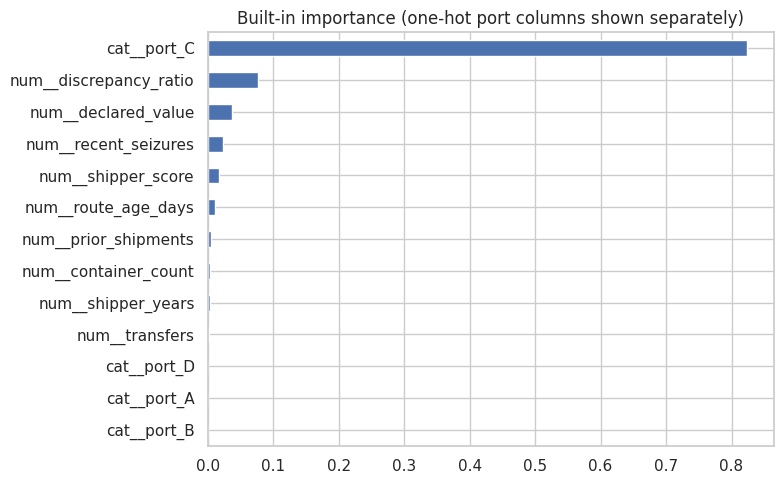

In [ ]:
# Permutation importance: shuffle one raw column at a time and measure how much the
# error grows. It works for any model and treats `port` as ONE feature.
perm = permutation_importance(best_reg, X_test, ys_test, n_repeats=30, random_state=SEED,
                              scoring="neg_root_mean_squared_error")
imp = pd.DataFrame({"feature": FEATURES, "importance": perm.importances_mean,
                    "std": perm.importances_std}).sort_values("importance", ascending=False)
display(imp.round(4))

plt.figure(figsize=(8, 5))
plt.barh(imp["feature"][::-1], imp["importance"][::-1], xerr=imp["std"][::-1])
plt.xlabel("Increase in RMSE when feature is shuffled")
plt.title(f"Permutation importance: {BEST_REG_NAME} (tuned)")
plt.tight_layout(); plt.show()

# Built-in importances (tree models only), as a second opinion
inner = best_reg.named_steps["model"]
if hasattr(inner, "feature_importances_"):
    names = best_reg.named_steps["prep"].get_feature_names_out()
    built_in = pd.Series(inner.feature_importances_, index=names).sort_values()
    built_in.plot.barh(figsize=(8, 5), title="Built-in importance (one-hot port columns shown separately)")
    plt.tight_layout(); plt.show()

In [ ]:
# ==========================================
# FINAL SCORE + DECISION PREDICTION
# ==========================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict BLACKBOX scores
test_scores = best_model.predict(X_test)

# Keep score inside valid 0-1 range
test_scores = np.clip(test_scores, 0, 1)

# Provisional decision rule
# score >= 0.5 -> APPROVE
# score < 0.5  -> DECLINE
predicted_decisions = np.where(
    test_scores >= 0.5,
    "APPROVE",
    "DECLINE"
)

# Regression evaluation
mae = mean_absolute_error(ys_test, test_scores)
rmse = np.sqrt(mean_squared_error(ys_test, test_scores))
r2 = r2_score(ys_test, test_scores)

print("FINAL MODEL RESULTS")
print("----------------------------")
print("MAE :", round(mae, 6))
print("RMSE:", round(rmse, 6))
print("R2  :", round(r2, 6))

# Show predictions
results = pd.DataFrame({
    "Actual Score": ys_test.values,
    "Predicted Score": test_scores,
    "Predicted Decision": predicted_decisions
})

print("\nPredictions:")
display(results)

print("\nAPPROVE predictions:",
      (results["Predicted Decision"] == "APPROVE").sum())

print("DECLINE predictions:",
      (results["Predicted Decision"] == "DECLINE").sum())

print("\n✅ Final prediction step completed")

FINAL MODEL RESULTS
----------------------------
MAE : 0.000739
RMSE: 0.00197
R2  : 0.9963

Predictions:


,Actual Score,Predicted Score,Predicted Decision
0,0.9765,0.976480,APPROVE
1,0.9757,0.975700,APPROVE
2,0.9759,0.975900,APPROVE
3,0.9765,0.976500,APPROVE
4,0.9765,0.976500,APPROVE
5,0.9765,0.976500,APPROVE
6,0.9763,0.976300,APPROVE
7,0.9693,0.973897,APPROVE
8,0.9765,0.976480,APPROVE
9,0.9738,0.974534,APPROVE



APPROVE predictions: 30
DECLINE predictions: 0

✅ Final prediction step completed


In [ ]:
from sklearn.base import clone
import pandas as pd
import numpy as np

# ==========================================
# TRAIN FINAL SCORE MODEL ON ALL DATA
# ==========================================

final_reg = clone(best_model)
final_reg.fit(X, y_score)

print("Final score model trained successfully ✅")


# ==========================================
# BLACKBOX PREDICTION FUNCTION
# ==========================================

def predict_blackbox(
    container_count,
    declared_value,
    discrepancy_ratio,
    port,
    prior_shipments,
    recent_seizures,
    route_age_days,
    shipper_score,
    shipper_years,
    transfers
):

    new_data = pd.DataFrame([{
        "container_count": container_count,
        "declared_value": declared_value,
        "discrepancy_ratio": discrepancy_ratio,
        "port": port,
        "prior_shipments": prior_shipments,
        "recent_seizures": recent_seizures,
        "route_age_days": route_age_days,
        "shipper_score": shipper_score,
        "shipper_years": shipper_years,
        "transfers": transfers
    }])

    # Predict score
    score = final_reg.predict(new_data)[0]

    # Keep score between 0 and 1
    score = np.clip(score, 0, 1)

    # Temporary decision rule
    if score >= 0.5:
        decision = "APPROVE"
    else:
        decision = "DECLINE"

    return {
        "score": round(float(score), 4),
        "decision": decision
    }


# ==========================================
# TEST THE FUNCTION
# ==========================================

example = predict_blackbox(
    80,     # container_count
    4,      # declared_value
    0.9,    # discrepancy_ratio
    "D",    # port
    0,      # prior_shipments
    4,      # recent_seizures
    27,     # route_age_days
    900,    # shipper_score
    31,     # shipper_years
    6       # transfers
)

print("\nExample prediction:")
print(example)

Final score model trained successfully ✅

Example prediction:
{'score': 0.9765, 'decision': 'APPROVE'}


**CONCLUSION**

In this project, we treated the cargo inspection service as a black-box machine-learning system. Since the internal model and its rules were unknown, we generated controlled shipment queries and observed the corresponding clearance scores and APPROVE/DECLINE decisions.

Using these observations, we created a dataset and trained machine-learning models to reproduce the behaviour of the hidden system. Regression was used to predict the clearance score, while classification was used to predict the final decision.

By comparing predictions with the actual black-box outputs and analysing feature importance, we were able to identify patterns in the system and build an approximate reconstruction of its decision-making process.

The key lesson from this experiment is that black-box models can be investigated by systematic querying, data collection, pattern analysis and machine-learning reconstruction. Rather than relying on assumptions about the meaning of the fields, our conclusions were based entirely on the observed behaviour of the system.